# Trabalho IA 2025/2026 - PopOut, MCTS e Decision Trees ID3

Este notebook apresenta uma solução para o jogo **PopOut**, uma variante do Connect Four onde cada jogador pode colocar peças no topo de uma coluna ou retirar uma peça própria da base("pop").

Além da implementação do jogo, o notebook inclui:

- uma IA baseada em **Monte Carlo Tree Search**;
- geração de datasets a partir de jogadas escolhidas pelo MCTS;
- uma árvore de decisão **ID3** implementada de raiz, sem `scikit-learn`;
- exemplo da implementação da árvore de decisão no dataset `iris`;
- um jogador baseado na árvore ID3;
- avaliação e comparação das AIs criadas.


## Imports e estruturas auxiliares

Esta célula importa bibliotecas standard usadas em todo o notebook:

- `random`, `math` e `copy` para o MCTS e para manipular estados do jogo;
- `csv`, `numpy`, `time` e `datetime` para gerar datasets e acompanhar o progresso;
- `Counter` e `defaultdict` para contagens usadas no ID3 e na deteção de repetições;
- `dataclass` e tipos de `typing` para tornar a árvore ID3 mais legível.
- `matplotlib.pyplot` para gerar representações gráficas dos resultados.


In [2]:
import random
import math
import copy
import csv
import time
import datetime
import numpy as np
from collections import Counter, defaultdict
from dataclasses import dataclass
from typing import Any, Dict, Optional
import matplotlib.pyplot as plt

## Classe `Poupout`: representação e regras do jogo

A classe `Poupout` é o núcleo do projeto. Ela representa o estado atual do jogo e disponibiliza os métodos necessários para jogar e avaliar posições.

Principais responsabilidades:

- criar e guardar o tabuleiro;
- executar jogadas `put`, `pop` e `draw`;
- alternar o jogador atual;
- verificar vitórias em linhas, colunas e diagonais;
- detetar tabuleiro cheio e repetição de estados;
- produzir cópias do estado para o MCTS;
- devolver a lista de jogadas legais para o jogador atual.
- criação e avaliação de tabuleiros aleatórios para a criação dos datasets

In [3]:
class Poupout:
    def __init__(self, rows, cols, moved="O", to_move="X"):
        #informações básicas do tabuleiro
        self.rows = rows                    
        self.cols = cols
        self.moved = moved
        self.to_move = to_move
        self.board = [["-" for _ in range(rows)] for _ in range(cols)]
        #informações adicionais para facilitar implementação de alguns métodos
        self.n_pieces = 0
        self.repeated = False
        self.last_move = None
        self.draw = False

    def display(self):
        print("  " + " ".join(str(i) for i in range(self.cols)))
        for r in range(self.rows):
            print("  ", end="")
            for c in range(self.cols):
                print(self.board[c][r], end="")
            print("")

    #usado para a criação do dataset
    def board_key(self):
        return tuple(tuple(col) for col in self.board), self.to_move

    def put(self, column):
        if column < 0 or column >= self.cols or self.board[column][0] != "-":
            raise Exception("Acao impossivel")
        for i in range(self.rows - 1, -1, -1):
            if self.board[column][i] == "-":
                self.board[column][i] = self.to_move
                self.n_pieces += 1
                return

    def pop(self, column):
        if column < 0 or column >= self.cols or self.board[column][-1] != self.to_move:
            raise Exception("Acao impossivel")
        self.board[column] = ["-"] + self.board[column][:-1]
        self.n_pieces -= 1

    def change_to_move(self):
        self.to_move, self.moved = self.moved, self.to_move

    def make_move(self, move, column):
        try:
            if move == "put":
                self.put(column)
            elif move == "pop":
                self.pop(column)
            elif move == "draw" and (self.repeated or self.check_full()):
                self.draw = True
            else:
                return False
            self.last_move = (move, column)
            return True
        except Exception:
            return False

    def check_row(self, row):
        line = "".join(self.board[c][row] for c in range(self.cols))
        if self.moved * 4 in line:
            return self.moved
        if self.to_move * 4 in line:
            return self.to_move
        return None

    def check_col(self, col):
        line = "".join(self.board[col][r] for r in range(self.rows))
        if self.moved * 4 in line:
            return self.moved
        if self.to_move * 4 in line:
            return self.to_move
        return None

    def check_diag1(self, row, col):
        cells = min(self.rows - row, self.cols - col)
        if cells < 4:
            return None
        line = "".join(self.board[col + i][row + i] for i in range(cells))
        if self.moved * 4 in line:
            return self.moved
        if self.to_move * 4 in line:
            return self.to_move
        return None

    def check_diag2(self, row, col):
        cells = min(self.rows - row, col + 1)
        if cells < 4:
            return None
        line = "".join(self.board[col - i][row + i] for i in range(cells))
        if self.moved * 4 in line:
            return self.moved
        if self.to_move * 4 in line:
            return self.to_move
        return None

    def check_win(self):
        if self.last_move is None:
            return None
        move, column = self.last_move
        adversary_win = False

        if move == "put":
            #verificar o local da ultima peça colocada
            row = None
            for r in range(self.rows):
                if self.board[column][r] == self.moved:
                    row = r
                    break

            for f in [lambda: self.check_row(row), lambda: self.check_col(column),
                      lambda: self.check_diag1(max(0, row - column), max(0, column - row)),
                      lambda: self.check_diag2(max(0, row - (self.cols - 1 - column)), min(self.cols - 1, row + column))]:
                winner = f()
                if winner is not None:
                    return winner

        elif move == "pop":
            #verificar a coluna da peça retirada
            for row in range(self.rows - 1, -1, -1):
                if self.board[column][row] == "-":
                    break
                for f in [lambda row=row: self.check_row(row),
                          lambda row=row: self.check_diag1(max(0, row - column), max(0, column - row)),
                          lambda row=row: self.check_diag2(max(0, row - (self.cols - 1 - column)), min(self.cols - 1, row + column))]:
                    winner = f()
                    if winner == self.moved:
                        return winner
                    if winner == self.to_move:
                        adversary_win = True
        #apenas verificar se adversãrio ganhou depois do jogador que jogou
        if adversary_win:
            return self.to_move
        return None

    def check_full(self):
        return self.n_pieces == self.rows * self.cols

    def check_repeat(self, state_counts):
        key = self.board_key()
        state_counts[key] += 1
        if state_counts[key] >= 3:
            self.repeated = True
        return self.repeated

    #auxiliares para a implementação de MCTS
    def clone(self):
        new = Poupout(self.rows, self.cols, self.moved, self.to_move)
        new.board = copy.deepcopy(self.board)
        new.n_pieces = self.n_pieces
        new.repeated = self.repeated
        new.last_move = self.last_move
        new.draw = self.draw
        return new

    def legal_moves(self):
        moves = []
        for c in range(self.cols):
            if self.board[c][0] == "-":
                moves.append(("put", c))
            if self.board[c][-1] == self.to_move:
                moves.append(("pop", c))
        if self.repeated or self.check_full():
            moves.append(("draw", 0))
        return moves
    
    def legal_put_moves(self):
        moves = []
        for c in range(self.cols):
            if self.board[c][0] == "-":
                moves.append(("put", c))
        return moves

    def is_terminal(self):
        return self.check_win() is not None or self.draw

    def get_result(self, maximizing_player):
        winner = self.check_win()
        if winner == maximizing_player:
            return 1
        if winner is not None:
            return -1
        return 0
    
    #auxiliares para criação dos datasets
    def random_board(self,n_pieces):
        for _ in range(n_pieces):
            moves=self.legal_put_moves()
            move=random.choice(moves)
            self.make_move(move[0], move[1])
            self.change_to_move()

    def full_check_win(self):
        adversary_win=False
        for r in range(self.rows):
            for f in [lambda row=r: self.check_row(row),
                        lambda row=r: self.check_diag1(row,0),
                        lambda row=r: self.check_diag2(row,self.cols-1)]:
                    winner = f()
                    if winner == self.moved:
                        return winner
                    if winner == self.to_move:
                        adversary_win = True
        for c in range(self.cols):
            for f in [lambda col=c: self.check_col(col),
                          lambda col=c: self.check_diag1(0,col),
                          lambda col=c: self.check_diag2(0,col)]:
                    winner = f()
                    if winner == self.moved:
                        return winner
                    if winner == self.to_move:
                        adversary_win = True
        if adversary_win:
            return self.to_move
        return None


## Classes `MCTSNode` e `MCTS`: jogador por Monte Carlo Tree Search

O MCTS constrói uma árvore de possibilidades a partir do estado atual. Cada nó guarda:

- o estado do jogo naquele ponto;
- a jogada que levou até esse estado;
- o nó pai e os filhos;
- número de visitas;
- pontuação acumulada;
- jogadas ainda não exploradas.

Cada iteração do MCTS passa por quatro fases:

1. **Selection**: desce pela árvore usando UCT.
2. **Expansion**: cria um novo filho com uma jogada ainda não testada.
3. **Simulation**: joga aleatoriamente até ao fim ou até uma profundidade máxima.
4. **Backpropagation**: propaga o resultado da simulação até à raiz.

No final, a jogada escolhida é a do filho da raiz com mais visitas, porque tende a ser a opção mais estável.


In [4]:
class MCTSNode:
    def __init__(self, game_state, parent=None, move=None):
        self.state = game_state
        self.parent = parent
        self.move = move
        self.children = []
        self.wins = 0.0
        self.visits = 0
        self._untried = game_state.legal_moves()
        random.shuffle(self._untried)

    def is_fully_expanded(self):
        return len(self._untried) == 0

    def uct_score(self, c=math.sqrt(2)):
        if self.visits == 0:
            return float("inf")
        return self.wins / self.visits + c * math.sqrt(math.log(self.parent.visits) / self.visits)

    def best_child(self, c=math.sqrt(2)):
        return max(self.children, key=lambda n: n.uct_score(c))

class MCTS:
    def __init__(self, iterations=600, c=math.sqrt(2), max_depth=40):
        self.iterations = iterations
        self.c = c
        self.max_depth = max_depth

    def choose_move(self, game_state):
        root = MCTSNode(game_state.clone())
        if not root._untried:
            return None
        original_player = game_state.to_move
        for _ in range(self.iterations):
            node = self._select(root)
            if not node.state.is_terminal():
                node = self._expand(node)
            result = self._simulate(node, original_player)
            self._backpropagate(node, result, original_player)
        return max(root.children, key=lambda n: n.visits).move

    def _select(self, node):
        while not node.state.is_terminal() and node.is_fully_expanded() and node.children:
            node = node.best_child(self.c)
        return node

    def _expand(self, node):
        if node._untried:
            move = node._untried.pop()
            new_game = node.state.clone()
            new_game.make_move(move[0], move[1])
            new_game.change_to_move()
            child = MCTSNode(new_game, parent=node, move=move)
            node.children.append(child)
            return child
        return node

    def _rollout_move(self, sim):
        moves = sim.legal_moves()
        return random.choice(moves)

    def _simulate(self, node, original_player):
        sim = node.state.clone()
        depth = 0
        while not sim.is_terminal() and depth < self.max_depth:
            moves = sim.legal_moves()
            if not moves:
                break
            action, col = self._rollout_move(sim)
            sim.make_move(action, col)
            sim.change_to_move()
            depth += 1
        return sim.get_result(original_player)

    def _backpropagate(self, node, result, original_player):
        while node is not None:
            node.visits += 1
            node_player = node.state.moved
            if node_player == original_player:
                node.wins += result
            else:
                node.wins -= result
            node = node.parent


## Função `play` e `simulate_games`: execução de uma partida IA vs IA

A função `play(player_X, player_O)` permite observar uma partida completa entre dois jogadores automáticos enquanto a `simulate_games` permite-nos simular multiplos jogos recebendo os resultados finais dos mesmos.


In [5]:
def play(player_X, player_O, show=True):
    ai_x = player_X
    ai_o = player_O

    jogo = Poupout(6, 7)
    state_counts = defaultdict(int)
    state_counts[jogo.board_key()] += 1

    while True:
        if show:
            jogo.display()
        winner = jogo.check_win()
        if winner is not None:
            if show:
                print(f"Parabens, {winner} ganhou!")
            break
        if jogo.draw:
            if show:
                print("Empate!")
            break

        jogador = ai_x if jogo.to_move == "X" else ai_o
        if show:
            print(f"IA ({jogo.to_move}) a pensar...")
        jogada = jogador.choose_move(jogo)
        action, col = jogada
        if show:
            print(f"  -> IA jogou: {action} coluna {col}")
        if jogada not in jogo.legal_moves():
            if show:
                print("Tentativa de jogada ilegal!")
            return None
        jogo.make_move(action, col)
        state_counts[jogo.board_key()] += 1
        jogo.check_repeat(state_counts)
        jogo.change_to_move()
    if winner is not None:
        return winner
    return None

def simulate_games(Player1, Player2, n_games):
    games_set1=[]
    games_set2=[]
    p1_wins=0
    p2_wins=0
    #como o primeiro a jogar tem uma clara vantagem são realizados jogos de ambos os lados
    for _ in range(n_games//2):
        players={"X":Player1, "O":Player2}
        games_set1.append(play(players["X"], players["O"], show=False))
    p1_wins+=games_set1.count("X")
    p2_wins+=games_set1.count("O")
    for _ in range(n_games//2):
        players={"X":Player2, "O":Player1}
        games_set2.append(play(players["X"], players["O"], show=False))
    p2_wins+=games_set2.count("X")
    p1_wins+=games_set2.count("O")
    games=games_set1 + games_set2
    return (p1_wins, p2_wins, games)

## Exemplo de jogo entre dois MCTS

A célula seguinte cria dois jogadores MCTS e coloca-os a jogar.


In [6]:
Iter_Jogador_X=10000
Iter_Jogador_O=10000
Jogador_X=MCTS(iterations=Iter_Jogador_X)
Jogador_O=MCTS(iterations=Iter_Jogador_O)
play(Jogador_X, Jogador_O)

  0 1 2 3 4 5 6
  -------
  -------
  -------
  -------
  -------
  -------
IA (X) a pensar...
  -> IA jogou: put coluna 3
  0 1 2 3 4 5 6
  -------
  -------
  -------
  -------
  -------
  ---X---
IA (O) a pensar...
  -> IA jogou: put coluna 3
  0 1 2 3 4 5 6
  -------
  -------
  -------
  -------
  ---O---
  ---X---
IA (X) a pensar...
  -> IA jogou: put coluna 4
  0 1 2 3 4 5 6
  -------
  -------
  -------
  -------
  ---O---
  ---XX--
IA (O) a pensar...
  -> IA jogou: put coluna 5
  0 1 2 3 4 5 6
  -------
  -------
  -------
  -------
  ---O---
  ---XXO-
IA (X) a pensar...
  -> IA jogou: put coluna 2
  0 1 2 3 4 5 6
  -------
  -------
  -------
  -------
  ---O---
  --XXXO-
IA (O) a pensar...
  -> IA jogou: put coluna 1
  0 1 2 3 4 5 6
  -------
  -------
  -------
  -------
  ---O---
  -OXXXO-
IA (X) a pensar...
  -> IA jogou: put coluna 5
  0 1 2 3 4 5 6
  -------
  -------
  -------
  -------
  ---O-X-
  -OXXXO-
IA (O) a pensar...
  -> IA jogou: put coluna 1
  0 1 2 3 4 5 6


'O'

## Geração do dataset PopOut

Para treinar a árvore ID3, cada posição do jogo é transformada num conjunto de atributos.

A função `state_to_features` cria uma linha do dataset com:

- uma coluna para cada casa do tabuleiro, como `c0_r0`, `c0_r1`, ...;
- o jogador que tem de jogar (`to_move`).
- os movimentos permitidos nesse estado, como `put_0`, `put_1`, ...;

A função `generate_popout_dataset` joga várias partidas usando MCTS e guarda, para cada estado, a jogada escolhida pelo MCTS. Essa jogada fica na coluna `move`, por exemplo `put_3` ou `pop_2`.

Vamos criar datasets usando MCTS com 100, 1000 e 10000 iterações, variando também se os datasets são criados a partir de jogos do zero ou de jogos aleatórios com cerca de 10 a 20 peças colocadas, sendo estes os momentos intermédios e finais de grande parte dos jogos.

In [6]:
def state_to_features(game):
    row = {}
    for c in range(game.cols):
        for r in range(game.rows):
            row[f"c{c}_r{r}"] = game.board[c][r]
    row["to_move"] = game.to_move
    for m in ["put", "pop"]:
        for c in range(game.cols):
            if (m,c) in game.legal_moves():
                row[f"{m}_{c}"]="T"
            else:
                row[f"{m}_{c}"]="F"
    return row

def generate_popout_dataset(n_base_games=0, n_random_games=0, mcts_iterations=120, max_depth=40, min_moves=3, outfile="popout_dataset.csv", show_progress=False, create=False):
    start=time.time()
    ai = MCTS(iterations=mcts_iterations, max_depth=max_depth)
    game_sizes=[]
    game_sizes.extend([0]*n_base_games)
    game_sizes.extend(np.random.normal(loc=15, scale=5, size=n_random_games))
    game_sizes=list(game_sizes)
    for g in range(len(game_sizes)):
        game_sizes[g]=int(game_sizes[g])
        if game_sizes[g]<0:
            game_sizes[g]=0
        elif game_sizes[g]>42:
            game_sizes[g]=42
    random.shuffle(game_sizes)
    rows = []
    perc=0

    for i,g in enumerate(game_sizes):
        if show_progress and (i/len(game_sizes))*100>=perc+10:
            perc+=10
            cur=time.time()
            elapsed=cur-start
            expected=(elapsed/perc)*100
            left=expected-elapsed
            print(f"{perc}%  Faltam {str(datetime.timedelta(seconds=left))}")
        while True:  
            new_rows=[]  
            game = Poupout(6, 7)
            game.random_board(g)
            if game.full_check_win() is not None:
                continue
            state_counts = defaultdict(int)
            state_counts[game.board_key()] += 1

            n_moves=0
            while True:
                if game.is_terminal():
                    break
                move = ai.choose_move(game)
                features = state_to_features(game)
                features["move"] = f"{move[0]}_{move[1]}"
                new_rows.append(features)
                game.make_move(move[0], move[1])
                n_moves+=1
                game.check_repeat(state_counts)
                game.change_to_move()
            #verificar se o jogo é relevante (tem mais que o mínimo de jogadas)
            if n_moves<min_moves:
                continue
            rows.extend(new_rows)
            break   

        fieldnames = list(rows[0].keys())
        with open(outfile, "a", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            if create and i==0:
                writer.writeheader()
            writer.writerows(new_rows)
    if show_progress:
        print("Done")

In [ ]:
generate_popout_dataset(n_base_games=3, n_random_games=100, mcts_iterations=100, min_moves=3, outfile="datasets/teste.csv", show_progress=True)

10%  Faltam 0:00:10.871137
20%  Faltam 0:00:09.376657
30%  Faltam 0:00:07.556560
40%  Faltam 0:00:07.177089
50%  Faltam 0:00:07.569203
60%  Faltam 0:00:06.554514
70%  Faltam 0:00:05.055916
80%  Faltam 0:00:03.519196
90%  Faltam 0:00:01.778347
Done


Criação de datasets base com jogos a partir do começo. É possível observar que, com o aumento de iterações para o MTCS utilizado, o número de jogos simulados tem de diminuir para que a geração dos datasets não demore demasiado.

In [ ]:
print("Dataset de 100 iterações de jogos normais:")
generate_popout_dataset(n_base_games=1000, mcts_iterations=100, outfile="datasets/popout_dataset_100_base.csv", show_progress=True, create=True)

Dataset de 100 iterações de jogos normais:
10%  Faltam 0:04:28.523399
20%  Faltam 0:04:00.289197
30%  Faltam 0:03:58.552094
40%  Faltam 0:03:21.144297
50%  Faltam 0:02:45.325854
60%  Faltam 0:02:11.930719
70%  Faltam 0:01:38.945938
80%  Faltam 0:01:05.971969
90%  Faltam 0:00:33.334688
Done


In [ ]:
print("Dataset de 1000 iterações de jogos normais:")
generate_popout_dataset(n_base_games=1000, mcts_iterations=1000, outfile="datasets/popout_dataset_1000_base.csv", show_progress=True, create=True)

Dataset de 1000 iterações de jogos normais:
10%  Faltam 0:44:09.758798
20%  Faltam 0:37:38.040708
30%  Faltam 0:33:42.235413
40%  Faltam 0:28:59.266176
50%  Faltam 0:24:14.380942
60%  Faltam 0:19:24.615706
70%  Faltam 0:14:28.915070
80%  Faltam 0:09:41.168812
90%  Faltam 0:04:49.783161
Done


Pelo facto do MCTS com 10000 iterações levar muito tempo, este dataset vai ser feito em partes para permitir a execução do código em várias ocasiões separadas:

In [ ]:
print("Dataset de 10000 iterações de jogos normais:")
generate_popout_dataset(n_base_games=100, mcts_iterations=10000, outfile="datasets/popout_dataset_10000_base.csv", show_progress=True, create=True)

Dataset de 10000 iterações de jogos normais:
10%  Faltam 1:43:10.885049
20%  Faltam 1:35:33.664183
30%  Faltam 1:29:31.390363
40%  Faltam 1:14:20.294096
50%  Faltam 0:55:43.789365
60%  Faltam 0:41:20.620992
70%  Faltam 0:30:37.652065
80%  Faltam 0:19:26.444472
90%  Faltam 0:09:18.370180
Done


In [ ]:
print("Dataset de 10000 iterações de jogos normais:")
generate_popout_dataset(n_base_games=100, mcts_iterations=10000, outfile="datasets/popout_dataset_10000_base.csv", show_progress=True)

Dataset de 10000 iterações de jogos normais:
10%  Faltam 1:35:46.470663
20%  Faltam 1:24:39.212876
30%  Faltam 1:11:43.274396
40%  Faltam 0:55:45.210170
50%  Faltam 0:44:00.975159
60%  Faltam 0:35:37.120212
70%  Faltam 0:28:14.919501
80%  Faltam 0:19:09.044137
90%  Faltam 0:09:53.855769
Done


In [ ]:
print("Dataset de 100 iterações de jogos aleatórios:")
generate_popout_dataset(n_random_games=1000, mcts_iterations=100, min_moves=5, outfile="datasets/popout_dataset_100_random.csv", show_progress=True, create=True)

Dataset de 100 iterações de jogos aleatórios:
10%  Faltam 0:02:51.197155
20%  Faltam 0:02:31.692633
30%  Faltam 0:02:11.564187
40%  Faltam 0:01:53.698851
50%  Faltam 0:01:34.081052
60%  Faltam 0:01:14.957805
70%  Faltam 0:00:55.816625
80%  Faltam 0:00:37.203352
90%  Faltam 0:00:18.355305
Done


In [ ]:
print("Dataset de 1000 iterações de jogos aleatórios:")
generate_popout_dataset(n_random_games=1000, mcts_iterations=1000, min_moves=5, outfile="datasets/popout_dataset_1000_random.csv", show_progress=True, create=True)

Dataset de 1000 iterações de jogos aleatórios:
10%  Faltam 0:23:32.426177
20%  Faltam 0:20:47.841002
30%  Faltam 0:18:40.252795
40%  Faltam 0:16:12.943762
50%  Faltam 0:13:27.425008
60%  Faltam 0:10:48.807680
70%  Faltam 0:08:04.002477
80%  Faltam 0:05:18.409413
90%  Faltam 0:02:37.966868
Done


In [ ]:
print("Dataset de 1000 iterações de jogos aleatórios:")
generate_popout_dataset(n_random_games=1000, mcts_iterations=10000, min_moves=5, outfile="datasets/popout_dataset_10000_random.csv", show_progress=True, create=True)

Dataset de 1000 iterações de jogos aleatórios:
10%  Faltam 3:37:59.338500
20%  Faltam 3:23:41.206192
30%  Faltam 2:54:16.925659
40%  Faltam 2:32:05.833781
50%  Faltam 2:07:00.226241
60%  Faltam 1:41:18.837349
70%  Faltam 1:16:46.860652
80%  Faltam 0:51:53.497936
90%  Faltam 0:26:00.221845
Done


## Árvore de decisão ID3

Esta secção implementa o algoritmo **ID3** sem usar bibliotecas externas de machine learning.

A árvore escolhe, em cada nó, o atributo com maior **ganho de informação**. Para isso usa:

- **entropia**, que mede a impureza das classes;
- **information gain**, que mede quanto um atributo reduz essa impureza;



In [7]:
@dataclass
class ID3Node:
    prediction: Any
    attribute: Optional[str] = None
    children: Optional[Dict[Any, "ID3Node"]] = None
    is_leaf: bool = False

    def classify(self, example):
        if self.is_leaf or self.attribute is None:
            return self.prediction
        value = example.get(self.attribute)
        if self.children and value in self.children:
            return self.children[value].classify(example)
        return self.prediction

    def pretty(self, indent=""):
        if self.is_leaf:
            return indent + f"Classe: {self.prediction}\n"
        s = indent + f"Se {self.attribute}:\n"
        for value, child in sorted(self.children.items(), key=lambda x: str(x[0])):
            s += indent + f"  = {value} ->\n"
            s += child.pretty(indent + "    ")
        return s

class ID3DecisionTree:
    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None
        self.label_col = None

    @staticmethod
    def entropy(labels):
        total = len(labels)
        counts = Counter(labels)
        return -sum((cnt/total) * math.log2(cnt/total) for cnt in counts.values() if cnt)

    def information_gain(self, rows, attribute, label_col):
        base = self.entropy([r[label_col] for r in rows])
        total = len(rows)
        parts = defaultdict(list)
        for r in rows:
            parts[r[attribute]].append(r)
        remainder = sum((len(part)/total) * self.entropy([r[label_col] for r in part]) for part in parts.values())
        return base - remainder

    def majority_label(self, rows, label_col):
        return Counter(r[label_col] for r in rows).most_common(1)[0][0]

    def fit(self, rows, label_col="label", attributes=None):
        if not rows:
            raise ValueError("Dataset vazio")
        self.label_col = label_col
        if attributes is None:
            attributes = [a for a in rows[0].keys() if a != label_col]
        self.root = self._id3(rows, attributes, label_col, depth=0)
        return self

    def _id3(self, rows, attributes, label_col, depth):
        labels = [r[label_col] for r in rows]
        majority = self.majority_label(rows, label_col)
        if len(set(labels)) == 1:
            return ID3Node(prediction=labels[0], is_leaf=True)
        if not attributes or len(rows) < self.min_samples_split or (self.max_depth is not None and depth >= self.max_depth):
            return ID3Node(prediction=majority, is_leaf=True)

        gains = [(self.information_gain(rows, a, label_col), a) for a in attributes]
        best_gain, best_attr = max(gains, key=lambda x: x[0])
        if best_gain <= 1e-12:
            return ID3Node(prediction=majority, is_leaf=True)

        node = ID3Node(prediction=majority, attribute=best_attr, children={}, is_leaf=False)
        values = sorted(set(r[best_attr] for r in rows), key=str)
        remaining = [a for a in attributes if a != best_attr]
        for v in values:
            subset = [r for r in rows if r[best_attr] == v]
            node.children[v] = self._id3(subset, remaining, label_col, depth + 1)
        return node

    def predict_one(self, example):
        if self.root is None:
            raise ValueError("A arvore ainda nao foi treinada")
        return self.root.classify(example)

    def predict(self, rows):
        return [self.predict_one(r) for r in rows]

    def score(self, rows, label_col=None):
        label_col = label_col or self.label_col
        preds = self.predict(rows)
        return sum(p == r[label_col] for p, r in zip(preds, rows)) / len(rows)

    def pretty(self):
        return self.root.pretty() if self.root else "<arvore vazia>"

## Funções auxiliares para treino e avaliação

Estas funções são usadas para preparar datasets e avaliar modelos:

- `train_test_split`: divide os dados em treino e teste;
- `discretize_numeric_dataset`: transforma atributos numéricos em bins, necessário para o ID3;
- `load_csv_dataset`: carrega datasets CSV;


In [8]:
def train_test_split(rows, test_ratio=0.25, seed=0):
    random.Random(seed).shuffle(rows)
    cut = int(len(rows) * (1 - test_ratio))
    return rows[:cut], rows[cut:]

def discretize_numeric_dataset(rows, label_col="label", bins=3):
    # Discretizacao por quantis: reduz tamanho da arvore e funciona bem no Iris.
    attrs = [a for a in rows[0] if a != label_col]
    thresholds = {}
    for a in attrs:
        vals = sorted(float(r[a]) for r in rows)
        qs = []
        for b in range(1, bins):
            idx = int(len(vals) * b / bins)
            qs.append(vals[idx])
        thresholds[a] = qs

    new_rows = []
    for r in rows:
        nr = {label_col: r[label_col]}
        for a in attrs:
            x = float(r[a])
            k = 0
            while k < len(thresholds[a]) and x > thresholds[a][k]:
                k += 1
            nr[a] = f"bin{k}"
        new_rows.append(nr)
    return new_rows, thresholds

def load_csv_dataset(path):
    with open(path) as file:
        ds=csv.DictReader(file)
        rows=[]
        for r in ds:
            rows.append(r)
        return rows

In [9]:
dataset_100_base=load_csv_dataset(path="datasets/popout_dataset_100_base.csv")
dataset_1000_base=load_csv_dataset(path="datasets/popout_dataset_1000_base.csv")
dataset_10000_base=load_csv_dataset(path="datasets/popout_dataset_10000_base.csv")
dataset_100_random=load_csv_dataset(path="datasets/popout_dataset_100_random.csv")
dataset_1000_random=load_csv_dataset(path="datasets/popout_dataset_1000_random.csv")
dataset_10000_random=load_csv_dataset(path="datasets/popout_dataset_10000_random.csv")

Observando os datasets gerados, decidimos que posteriormente neste notebook queremos testar uma variação dos mesmos, retratando cada célula do tabuleiro não apenas como uma peçan mas como a perspetiva do jogador.

Para isso retiramos o atributo `to_move` e substituímos todos os dados das peças de `X` e  `O` para `P` e `A`, representando player e adversary respetivamente. 

Esperamos que este dataset reforce a diferença entre dois tabuleiros que parecem semelhantes, mas são bastante diferentes quando vistos das perspetivas dos jogadores alterando as suas performances nas simulações.

In [10]:
def change_feature(feature):
    new_feature={}
    for atr in feature:
        if feature[atr]=="T" or feature[atr]=="F" or atr=="move":
            new_feature[atr]=feature[atr]
            continue
        if atr=="to_move":
            continue
        if feature[atr]==feature["to_move"]:
            new_feature[atr]="P"
        elif feature[atr]!="-":
            new_feature[atr]="A" 
        else:
            new_feature[atr]="-"
    return new_feature
def change_dataset(rows):
    new_rows=[]
    for r in rows:
        new_rows.append(change_feature(r))
    return new_rows

Exemplo: treinar ID3 com dataset PopOut


## Iris: carregar, discretizar e treinar

Coloca o ficheiro `iris.csv` na mesma pasta do notebook com as colunas: `sepal_length`, `sepal_width`, `petal_length`, `petal_width`, `label`.

In [ ]:
# Exemplo para quando tiveres o ficheiro iris.csv
iris_rows = load_csv_dataset("datasets/iris.csv")
iris_disc, thresholds = discretize_numeric_dataset(iris_rows, label_col="Species", bins=3)
train, test = train_test_split(iris_disc, test_ratio=0.25, seed=2)
iris_tree = ID3DecisionTree(max_depth=None).fit(train, label_col="Species")
print("Accuracy treino:", iris_tree.score(train, "Species"))
print("Accuracy teste:", iris_tree.score(test, "Species"))
print("Thresholds usados:", thresholds)
print(iris_tree.pretty())

Accuracy treino: 1.0
Accuracy teste: 0.9736842105263158
Thresholds usados: {'Id': [51.0, 101.0], 'SepalLengthCm': [5.4, 6.3], 'SepalWidthCm': [2.9, 3.2], 'PetalLengthCm': [3.0, 4.9], 'PetalWidthCm': [1.0, 1.6]}
Se Id:
  = bin0 ->
    Se SepalLengthCm:
      = bin0 ->
        Classe: Iris-setosa
      = bin1 ->
        Classe: Iris-setosa
      = bin2 ->
        Classe: Iris-versicolor
  = bin1 ->
    Classe: Iris-versicolor
  = bin2 ->
    Classe: Iris-virginica



## Jogador baseado em ID3

A classe `ID3DecisionTreePlayer` transforma uma árvore ID3 treinada num jogador de PopOut.

Quando recebe um estado do jogo:

1. converte o estado em atributos com `state_to_features`;
2. usa a árvore para prever a jogada;
3. converte a previsão, por exemplo `put_3`, para o formato usado pelo jogo: `("put", 3)`.

Esta IA é mais rápida a decidir do que o MCTS, mas depende da qualidade do dataset usado no treino.


In [11]:
class ID3DecisionTreePlayer:
    def __init__(self, tree, changed_feature=False):
        self.tree=tree
        self.changed_feature=changed_feature

    def choose_move(self, state):
        game=state_to_features(state)
        if self.changed_feature:
            game=change_feature(game)
        move=self.tree.predict_one(game)
        move=move.split("_")
        return (move[0], int(move[1]))

In [49]:
tree = ID3DecisionTree(max_depth=10)
tree.fit(dataset_100_base, label_col="move")
Player=ID3DecisionTreePlayer(tree)
jogo=Poupout(6,7)
jogo.display()
print(Player.choose_move(jogo))

  0 1 2 3 4 5 6
  -------
  -------
  -------
  -------
  -------
  -------
('put', 3)


In [56]:
tree1 = ID3DecisionTree(max_depth=20)
tree1.fit(dataset_100_base, label_col="move")
tree2 = ID3DecisionTree(max_depth=20)
tree2.fit(dataset_100_random, label_col="move")
Player_X=ID3DecisionTreePlayer(tree2)
Player_O=ID3DecisionTreePlayer(tree1)
play(Player_X, Player_O)

  0 1 2 3 4 5 6
  -------
  -------
  -------
  -------
  -------
  -------
IA (X) a pensar...
  -> IA jogou: put coluna 1
  0 1 2 3 4 5 6
  -------
  -------
  -------
  -------
  -------
  -X-----
IA (O) a pensar...
  -> IA jogou: put coluna 3
  0 1 2 3 4 5 6
  -------
  -------
  -------
  -------
  -------
  -X-O---
IA (X) a pensar...
  -> IA jogou: put coluna 3
  0 1 2 3 4 5 6
  -------
  -------
  -------
  -------
  ---X---
  -X-O---
IA (O) a pensar...
  -> IA jogou: put coluna 3
  0 1 2 3 4 5 6
  -------
  -------
  -------
  ---O---
  ---X---
  -X-O---
IA (X) a pensar...
  -> IA jogou: put coluna 3
  0 1 2 3 4 5 6
  -------
  -------
  ---X---
  ---O---
  ---X---
  -X-O---
IA (O) a pensar...
  -> IA jogou: put coluna 4
  0 1 2 3 4 5 6
  -------
  -------
  ---X---
  ---O---
  ---X---
  -X-OO--
IA (X) a pensar...
  -> IA jogou: pop coluna 1
  0 1 2 3 4 5 6
  -------
  -------
  ---X---
  ---O---
  ---X---
  ---OO--
IA (O) a pensar...
  -> IA jogou: put coluna 5
  0 1 2 3 4 5 6


'O'

## Experiencias com  as Ais criadas.

Agora que temos os dois algoritmos que queremos estudar implementados podemos começar a experimentar com as diferentes Ais possíveis simulando vários jogos entre as mesmas.

Para ajudar nos testes, criaremos um jogador aleatório para ajudar a demonstrar que as AIs criadas são melhores que jogar à sorte e também funções para criar jogadores de árvores de decisão com diferentes datasets e profundidades bem como uma função feita para comparar várias Ais colocando umas contra as outras.

In [12]:
class RandomPlayer():
    def choose_move(self, state):
        moves=state.legal_moves()
        return random.choice(moves)

In [13]:
def create_tree_players(normal_datasets=None, changed_datasets=None, depths=None):
    players={}
    if normal_datasets is not None:
        for p in normal_datasets:
            for d in depths:
                tree=ID3DecisionTree(max_depth=d)
                tree.fit(normal_datasets[p],label_col="move")        
                players[f"{p}_{d}"]=ID3DecisionTreePlayer(tree)
    if changed_datasets is not None:
        for p in changed_datasets:
            for d in depths:
                tree=ID3DecisionTree(max_depth=d)
                tree.fit(changed_datasets[p],label_col="move")        
                players[f"{p}_{d}"]=ID3DecisionTreePlayer(tree,changed_feature=True)
    return players

def compare_players(normal_players=None, tree_players=None, normal_vs_trees=False, n_games=0):
    results={}
    if normal_vs_trees and (normal_players is None or tree_players is None):
        return None
    if normal_vs_trees:
        for p in normal_players:
            results[f"{p} wins"]=0
        for p in tree_players:
            results[f"{p} wins"]=0
        for p1 in normal_players:
            for p2 in tree_players:
                result=simulate_games(normal_players[p1],tree_players[p2],n_games)
                results[f"{p1} wins"]+=result[0]
                results[f"{p2} wins"]+=result[1]
    else:
        players={}
        if normal_players is not None:
            players.update(normal_players)
        if tree_players is not None:
            players.update(tree_players)
        for p in players:
            results[f"{p} wins"]=0
        for i, p1 in enumerate(list(players.keys())):
            for p2 in list(players.keys())[i+1:]:
                result=simulate_games(players[p1],players[p2],n_games)
                results[f"{p1} wins"]+=result[0]
                results[f"{p2} wins"]+=result[1]
    for p in results:
        print(f"{p}: {results[p]}")
    return results

## Experiência MCTS: número de iterações

Compara jogadores MCTS com diferentes orçamentos de iterações.

Comparação entre AIs MCTS:

In [14]:
results={}

In [ ]:
players={"random":RandomPlayer(), "mcts_100":MCTS(iterations=100), "mcts_1000":MCTS(iterations=1000), "mcts_10000":MCTS(iterations=10000)}
results[1]=compare_players(normal_players=players,n_games=100)

random wins: 2
mcts_100 wins: 105
mcts_1000 wins: 207
mcts_10000 wins: 282


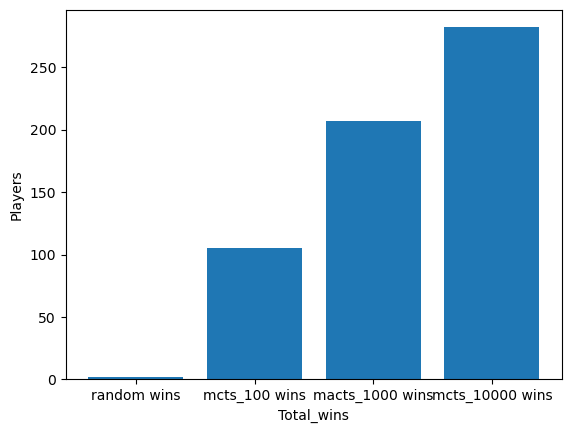

In [42]:
players=list(results[1].keys())
wins=list(results[1].values())
plt.bar(players, wins)
plt.xlabel('Total_wins')
plt.ylabel('Players')
plt.show()

Comparação de AIs de árvores de decisão contras o Random player:

In [14]:
depths=[10,20,40,None]
normal_players={"random":RandomPlayer()}
tree_player_names={"ID3_100":dataset_100_base,
                   "ID3_1000":dataset_1000_base,
                   "ID3_10000":dataset_10000_base}
tree_players=create_tree_players(normal_datasets=tree_player_names,depths=depths)
results[2]=compare_players(normal_players=normal_players, tree_players=tree_players, normal_vs_trees=True, n_games=1000)

random wins: 391
ID3_100_10 wins: 909
ID3_100_20 wins: 861
ID3_100_40 wins: 855
ID3_100_None wins: 854
ID3_1000_10 wins: 827
ID3_1000_20 wins: 827
ID3_1000_40 wins: 848
ID3_1000_None wins: 849
ID3_10000_10 wins: 714
ID3_10000_20 wins: 742
ID3_10000_40 wins: 724
ID3_10000_None wins: 729


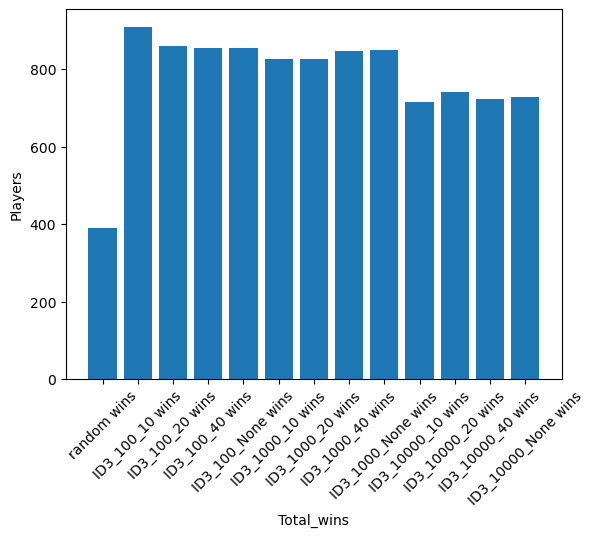

In [28]:
players=list(results[2].keys())
wins=list(results[2].values())
plt.bar(players, wins)
plt.xlabel('Total_wins')
plt.ylabel('Players')
plt.xticks(rotation=45)
plt.show()

Como podemos observar por estes resultados, as árvores de decisão conseguiram ter um desempenho superior ao jogador aleatório, tendo também em consideração que existe um número bem reduzido de vitórias em proporção à quantidade de jogos efetuados, devido a empates dados pela tentativa de efetuar jogadas ilegais por parte das árvores.

Comparação entre as árvores de decisão base:

In [24]:
depths=[10,20,40,None]
tree_player_names={"ID3_100":dataset_100_base,
                   "ID3_1000":dataset_1000_base,
                   "ID3_10000":dataset_10000_base}
tree_players=create_tree_players(normal_datasets=tree_player_names,depths=depths)
results[3]=compare_players(tree_players=tree_players, n_games=2)

ID3_100_10 wins: 0
ID3_100_20 wins: 3
ID3_100_40 wins: 3
ID3_100_None wins: 3
ID3_1000_10 wins: 12
ID3_1000_20 wins: 12
ID3_1000_40 wins: 12
ID3_1000_None wins: 12
ID3_10000_10 wins: 7
ID3_10000_20 wins: 7
ID3_10000_40 wins: 7
ID3_10000_None wins: 7


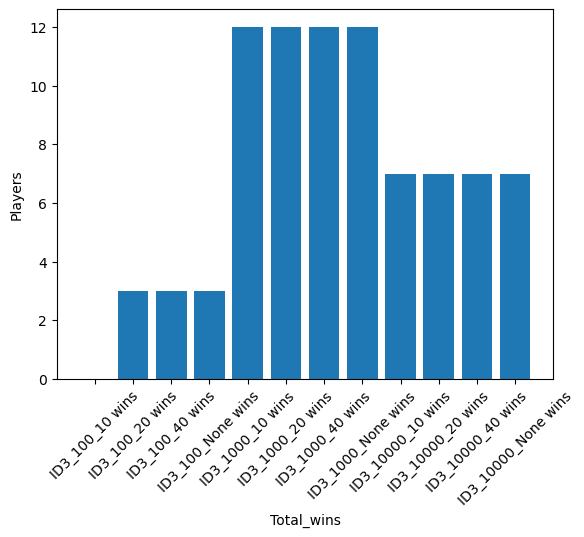

In [30]:
players=list(results[3].keys())
wins=list(results[3].values())
plt.bar(players, wins)
plt.xlabel('Total_wins')
plt.ylabel('Players')
plt.xticks(rotation=45)
plt.show()

Quando avaliadas contra elas próprias, as árvores demonstram resultados extremamente semelhantes e específicos, isto porque uma árvore escolherá sempre a mesma jogada quando colocada na mesma situação, fazendo com que 2 jogos entre as mesmas árvores resultem sempre no mesmo resultado. Além disso, podemos observar outra vez o mesmo problema com jogadas ilegais do outro teste.

Comparação das árvores de decisão base contra as com jogos aleatórios:

In [26]:
depths=[10,None]
tree_player_names={"ID3_100":dataset_100_base,
                   "ID3_1000":dataset_1000_base,
                   "ID3_10000":dataset_10000_base,
                   "ID3_random_100":dataset_100_random,
                   "ID3_random_1000":dataset_1000_random,
                   "ID3_random_10000":dataset_10000_random}
tree_players=create_tree_players(normal_datasets=tree_player_names,depths=depths)
results[4]=compare_players(tree_players=tree_players, n_games=2)

ID3_100_10 wins: 6
ID3_100_None wins: 10
ID3_1000_10 wins: 10
ID3_1000_None wins: 11
ID3_10000_10 wins: 9
ID3_10000_None wins: 8
ID3_random_100_10 wins: 5
ID3_random_100_None wins: 4
ID3_random_1000_10 wins: 6
ID3_random_1000_None wins: 3
ID3_random_10000_10 wins: 7
ID3_random_10000_None wins: 9


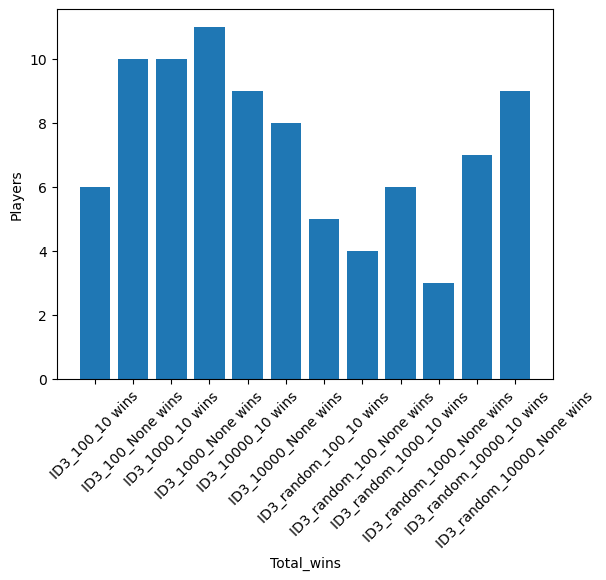

In [31]:
players=list(results[4].keys())
wins=list(results[4].values())
plt.bar(players, wins)
plt.xlabel('Total_wins')
plt.ylabel('Players')
plt.xticks(rotation=45)
plt.show()

Comparando os datasets criados a partir de jogos completos com aqueles criados a partir de jogos aleatórios podemos concluir que os de jogos iniciais conseguem ganhar a maior parte dos jogos. Isto demonstra a vantagem em ter exemplos de um jogo nos estados inicial, médio e final em vez de vários exemplos de jogos sem estado inicial. Isto não torna os datasets aleatórios inúteis, já que podemos sempre experimentar com a sua adição aos datasets base.

Comparação da melhor árvore atual contra árvores geradas com datasets mistos:

In [32]:
dataset_100_misto1=dataset_100_base + dataset_100_random[:len(dataset_100_random)//4]
dataset_100_misto2=dataset_100_base + dataset_100_random[:len(dataset_100_random)//2]
dataset_100_misto3=dataset_100_base + dataset_100_random
dataset_1000_misto1=dataset_1000_base + dataset_1000_random[:len(dataset_1000_random)//4]
dataset_1000_misto2=dataset_1000_base + dataset_1000_random[:len(dataset_1000_random)//2]
dataset_1000_misto3=dataset_1000_base + dataset_1000_random
dataset_10000_misto1=dataset_10000_base + dataset_10000_random[:len(dataset_10000_random)//4]
dataset_10000_misto2=dataset_10000_base + dataset_10000_random[:len(dataset_10000_random)//2]
dataset_10000_misto3=dataset_10000_base + dataset_10000_random
depths=[10,None]
tree_player_names={"ID3_1000":dataset_1000_base,
              "ID3_misto1_100":dataset_100_misto1,
              "ID3_misto2_100":dataset_100_misto2,
              "ID3_misto3_100":dataset_100_misto3,                            
              "ID3_misto1_1000":dataset_1000_misto1,
              "ID3_misto2_1000":dataset_1000_misto2,
              "ID3_misto3_1000":dataset_1000_misto3,       
              "ID3_misto1_10000":dataset_10000_misto1,
              "ID3_misto2_10000":dataset_10000_misto2,
              "ID3_misto3_10000":dataset_10000_misto3,       
              }
tree_players=create_tree_players(normal_datasets=tree_player_names,depths=depths)
results[5]=compare_players(tree_players=tree_players, n_games=2)

ID3_1000_10 wins: 17
ID3_1000_None wins: 17
ID3_misto1_100_10 wins: 4
ID3_misto1_100_None wins: 9
ID3_misto2_100_10 wins: 9
ID3_misto2_100_None wins: 7
ID3_misto3_100_10 wins: 2
ID3_misto3_100_None wins: 5
ID3_misto1_1000_10 wins: 10
ID3_misto1_1000_None wins: 19
ID3_misto2_1000_10 wins: 25
ID3_misto2_1000_None wins: 18
ID3_misto3_1000_10 wins: 19
ID3_misto3_1000_None wins: 21
ID3_misto1_10000_10 wins: 23
ID3_misto1_10000_None wins: 23
ID3_misto2_10000_10 wins: 19
ID3_misto2_10000_None wins: 19
ID3_misto3_10000_10 wins: 16
ID3_misto3_10000_None wins: 16


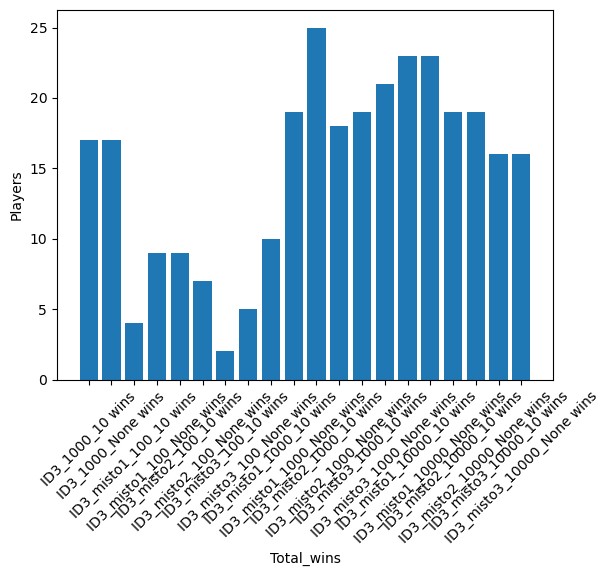

In [35]:
players=list(results[5].keys())
wins=list(results[5].values())
plt.bar(players, wins)
plt.xlabel('Total_wins')
plt.ylabel('Players')
plt.xticks(rotation=45)
plt.show()

Aqui conseguimos reparar que alguns dos datasets mistos tiveram resultados bem superiores aos do dataset de 1000 iterações (o melhor até ao momento). Isto demonstra a vantagem em adicionar situações aleatórias aos datasets como modo de aumentar a diversidade da informação que possuem. Podemos também notar que os datasets "misto3", correspondentes à soma completa dos datasets base e aleatórios têm performances piores que os outros mistos de modo geral, o que nos dá uma melhor noção da importância de colocar a informação adicional numa proporção mais reduzida que a base.

Comparação das melhores árvores contra as suas versões alteradas

In [36]:
dataset_1000_base_changed=change_dataset(dataset_1000_base)
dataset_1000_misto2_changed=change_dataset(dataset_1000_misto2)
dataset_10000_misto1_changed=change_dataset(dataset_10000_misto1)
depths=[10,None]
tree_player_names={"ID3_1000":dataset_1000_base,                          
              "ID3_misto2_1000":dataset_1000_misto2,     
              "ID3_misto1_10000":dataset_10000_misto1}
tree_changed_player_names={"ID3_1000_changed":dataset_1000_base_changed,  
                           "ID3_misto2_1000_changed":dataset_1000_misto2_changed,     
                           "ID3_misto1_10000_changed":dataset_10000_misto1_changed}
tree_players=create_tree_players(normal_datasets=tree_player_names,changed_datasets=tree_changed_player_names,depths=depths)
results[6]=compare_players(tree_players=tree_players, n_games=2)

ID3_1000_10 wins: 7
ID3_1000_None wins: 7
ID3_misto2_1000_10 wins: 13
ID3_misto2_1000_None wins: 7
ID3_misto1_10000_10 wins: 13
ID3_misto1_10000_None wins: 15
ID3_1000_changed_10 wins: 1
ID3_1000_changed_None wins: 7
ID3_misto2_1000_changed_10 wins: 2
ID3_misto2_1000_changed_None wins: 7
ID3_misto1_10000_changed_10 wins: 7
ID3_misto1_10000_changed_None wins: 8


In [ ]:
players=list(results[6].keys())
wins=list(results[6].values())
plt.bar(players, wins)
plt.xlabel('Total_wins')
plt.ylabel('Players')
plt.xticks(rotation=45)
plt.show()

Como apresentado, a conclusão que retiramos é que os datasets alterados têm um desempenho constantemente inferior aos normais.
Com este teste não só percebemos a importância de todos os atributos do dataset para chegar a uma jogada final mais conveniente para a sua vitória mas também determinamos os melhores datasets para a criação de uma árvore de decisão para jogar Popout:
- datasets mistos de 1000 e 10000 iterações, que apresentaram um desempenho constantemente bom durante os testes todos
- dataset misto de 10000 iterações alterado que embora não tenha sido realmente o mais forte neste teste, foi o melhor alterado, o que nos leva a querer testa-lo na experiência final entre ele e os jogadores MCTS.

In [18]:
tree_player_names={"ID3_misto2_1000":dataset_1000_misto2,     
                   "ID3_misto1_10000":dataset_10000_misto1}    
tree_changed_player_names={"ID3_misto1_10000_changed":dataset_10000_misto1_changed}
tree_players=create_tree_players(normal_datasets=tree_player_names, changed_datasets=tree_changed_player_names, depths=[10, None])
normal_players={"random": RandomPlayer()}
results[7]=compare_players(normal_players=normal_players, tree_players=tree_players, normal_vs_trees=True, n_games=10)

random wins: 3
ID3_misto2_1000_10 wins: 8
ID3_misto2_1000_None wins: 7
ID3_misto1_10000_10 wins: 5
ID3_misto1_10000_None wins: 8
ID3_misto1_10000_changed_10 wins: 8
ID3_misto1_10000_changed_None wins: 7


In [ ]:
normal_players={"mcts_100": MCTS(iterations=100)}
results[8]=compare_players(normal_players=normal_players, tree_players=tree_players, normal_vs_trees=True, n_games=10)

mcts_100 wins: 35
ID3_misto2_1000_10 wins: 5
ID3_misto2_1000_None wins: 4
ID3_misto1_10000_10 wins: 2
ID3_misto1_10000_None wins: 3
ID3_misto1_10000_changed_10 wins: 3
ID3_misto1_10000_changed_None wins: 1


In [ ]:
normal_players={"mcts_1000": MCTS(iterations=1000)}
results[9]=compare_players(normal_players=normal_players, tree_players=tree_players, normal_vs_trees=True, n_games=10)

mcts_1000 wins: 51
ID3_misto2_1000_10 wins: 1
ID3_misto2_1000_None wins: 1
ID3_misto1_10000_10 wins: 3
ID3_misto1_10000_None wins: 0
ID3_misto1_10000_changed_10 wins: 0
ID3_misto1_10000_changed_None wins: 0


In [ ]:
normal_players={"mcts_10000": MCTS(iterations=10000)}
results[10]=compare_players(normal_players=normal_players, tree_players=tree_players, normal_vs_trees=True, n_games=10)

mcts_10000 wins: 47
ID3_misto2_1000_10 wins: 0
ID3_misto2_1000_None wins: 0
ID3_misto1_10000_10 wins: 2
ID3_misto1_10000_None wins: 1
ID3_misto1_10000_changed_10 wins: 4
ID3_misto1_10000_changed_None wins: 4


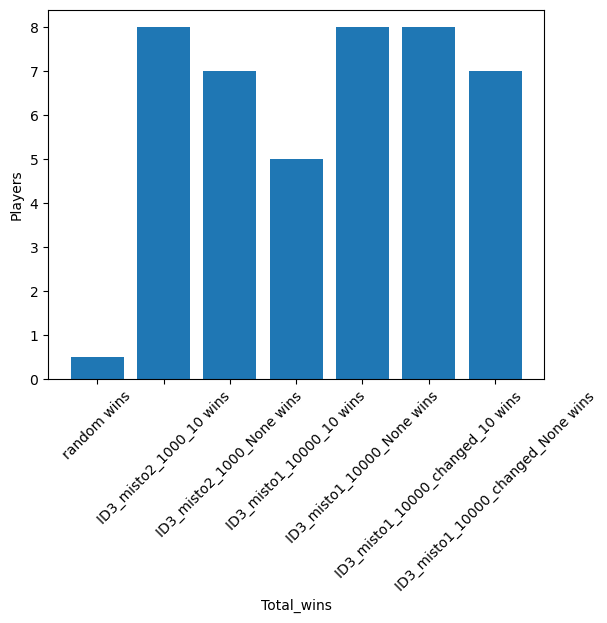

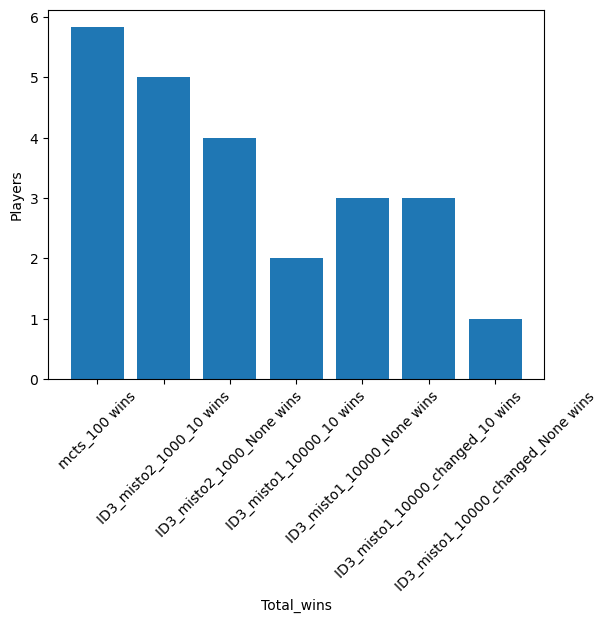

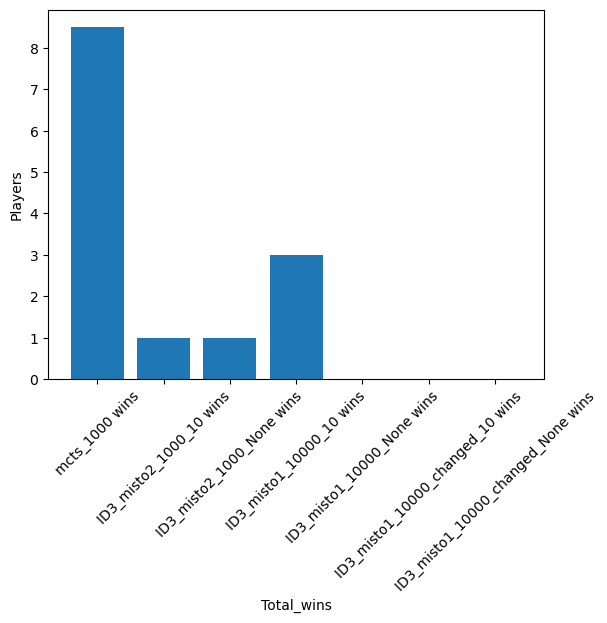

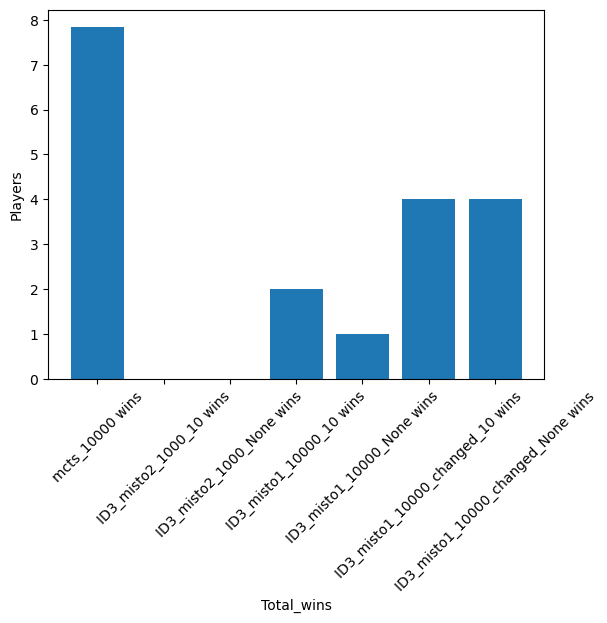

<Figure size 640x480 with 0 Axes>

In [ ]:
for i in range(7,11):
    players=list(results[i].keys())
    wins=list(results[i].values())
    wins[0]/=6
    plt.bar(players, wins)
    plt.xlabel('Total_wins')
    plt.ylabel('Players')
    plt.xticks(rotation=45)
    plt.show()
    plt.clf()

Podemos observar que as melhores árvores de decisão que criamos têm capacidade suficiente para derrotar consistentemente o random player, equiparar-se com o MCTS com 100 iterações e, em casos especificos até ganhar aos algoritmos de 1000 e 10000 iterações.

É importante também observar que, no caso dos dois algoritmos mais fortes, as árvores que mais problemas lhes causaram foram criadas a partir de datasets diferentes, demonstrando que é possível adaptar datasets ao estilo de jogo de diferentes algoritmos

## Conclusões

Após todos os testes realizados para avaliar os algoritmos MCTS e ID3 a jogarem Popout, podemos tirar conclusões claras sobre as suas performances:

- MCTS é um algoritmo mais completo que se consegue adaptar a qualquer situação de jogo, conseguindo obter resultados bem melhores no que toca a qualidade das suas jogadas e em vitórias, tendo de sacrificar tempo para conseguir esses mesmos resultados

- As árvores de decisão ID3 apresentam resultados bem inferiores mesmo após ajustar a sua profundidade máxima e o dataset em que se baseia, apresentando enormes dificuldades em reconhecer os padrões de jogadas legais. Mesmo assim, elas apresentaram melhor qualidade que um jogador aleatório e, salvo o tempo necessário para criar o dataset ou treinar a árvore, apresentam velocidade bastante superior à do MCTS, sendo então uma opção viável para aplicar no caso de um nível mais fácil.

Chegamos à conclusão então de que, mesmo com uma maior demora no processamento das jogadas, o MCTS apresenta melhores resultados de qualidade de jogo em relação ao tempo demorado embora as árvores ID3 ainda possam apresentar utilidade na aplicação de uma AI para jogar Popout.